In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import PowerNorm

data = pd.read_csv("data/Raw Data.csv", sep=',')
data = data.drop(columns=["time", "seconds_elapsed", "bearingAccuracy", "bearing", "altitude", "verticalAccuracy"])
data = data.rename(columns={"latitude": "lat", "longitude": "long", "speed": "speed", "speedAccuracy":"speedAcc", "horizontalAccuracy":"horiAcc"})
data["speed"] = data["speed"] * 3.6
data = data.dropna(subset=['speed'])

start_lat = data['lat'].iloc[0]
start_long = data['long'].iloc[0]
data['x_meters'] = (data['long'] - start_long) * 94800
data['y_meters'] = (data['lat'] - start_lat) * 110852

In [ ]:
print(f"Mean Speed: {data['speed'].mean():.2f} km/h")
print(f"Median Speed: {data['speed'].median():.2f} km/h")
print(f"Max Speed: {data['speed'].max():.2f} km/h")
print(f"Min Non-Zero Speed: {data['speed'][data['speed'] > 0].min():.2f} km/h")

print("\nHorizaontal Accuracy:")

print(f"Mean Accuracy: {data['horiAcc'].mean():.2f} m")
print(f"Median Accuracy: {data['horiAcc'].median():.2f} m")
print(f"Max Accuracy: {data['horiAcc'].max():.2f} m")
print(f"Min Accuracy: {data['horiAcc'].min():.2f} m")

print("\nSpeed Accuracy:")

print(f"Mean Accuracy: {data['speedAcc'].mean():.2f} km/h")
print(f"Median Accuracy: {data['speedAcc'].median():.2f} km/h")
print(f"Max Accuracy: {data['speedAcc'].max():.2f} km/h")
print(f"Min Accuracy: {data['speedAcc'].min():.2f} km/h")

Mean Speed: 10.14 km/h
Median Speed: 9.90 km/h
Max Speed: 30.85 km/h
Min Non-Zero Speed: 0.68 km/h

Horizaontal Accuracy:
Mean Accuracy: 9.57 m
Median Accuracy: 9.94 m
Max Accuracy: 12.26 m
Min Accuracy: 3.79 m

Speed Accuracy:
Mean Accuracy: 0.88 m
Median Accuracy: 0.53 m
Max Accuracy: 3.76 m
Min Accuracy: 0.07 m


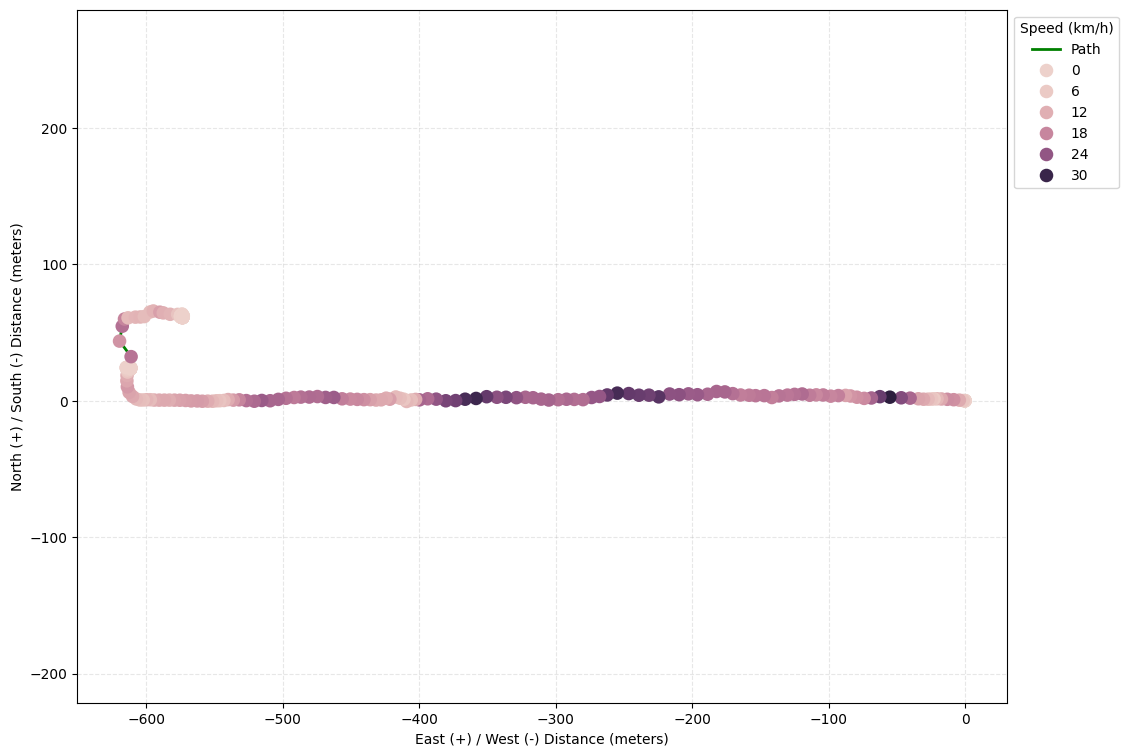

In [7]:
plt.figure(figsize=(12, 9))

plt.plot(data['x_meters'], data['y_meters'], color='green', linewidth=2, zorder=1, label='Path')
sns.scatterplot(data=data, x='x_meters', y='y_meters', hue='speed', hue_norm=PowerNorm(gamma=2), s=60, edgecolor=None, linewidth=2, zorder=2)

plt.ylabel("North (+) / South (-) Distance (meters)")
plt.xlabel("East (+) / West (-) Distance (meters)")

plt.legend(title="Speed (km/h)", bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.axis('equal')
plt.show()